After correcting the egagement rate definition to (likes + dislikes + comments) / views, the relationship between views and engagement shifted from strongly positive to slightly negative. This makes more sense as views is now prominantly in the denominator, engagement measures density, and the largest audiences interact less than niche audiences. 

What is correlative is views to likes (0.87), views to dislikes (0.87), and views to comments (0.78). What is not correlative is views to our like to dislike ratio (0.10). This correlation is very weak to prove the theory that "polarizing" videos get the most shares. What the data is demonstrating that views, likes, dislikes, and comment counts are driven by the number of views. 

To further investigate the matter, I will split the data into quantiles of like to dislike ratio, analyzing how the highest quantile of ratio compares to the lowest.

In [22]:
# splitting ratio into quantiles
quantiles = all_df_video['likes_to_dislikes'].quantile(
    [0.1, 0.25, 0.5, 0.75, 0.9]
)
print(quantiles)

0.10     4.902067
0.25    12.338705
0.50    27.588235
0.75    54.981998
0.90    95.358536
Name: likes_to_dislikes, dtype: float64


In [23]:
# applying quantiles to define a new column
all_df_video['Ratio Tier'] = pd.qcut(
    all_df_video['likes_to_dislikes'],
    q=3,
    labels=['Extreme', 'Major', 'Typical']
)
print(all_df_video['Ratio Tier'].value_counts(normalize=True)) # validating the share of each tier

Ratio Tier
Extreme    0.333333
Major      0.333333
Typical    0.333333
Name: proportion, dtype: float64


In [24]:
# each tier shares exactly a third of the data
# grouping by tier and median views in log scale
tiers_by_views = all_df_video.groupby('Ratio Tier', observed=True)['views'].apply( # observed True to ignore false values of which are none
    lambda x: np.log10(x)
    .median()
)
print(tiers_by_views)

Ratio Tier
Extreme    5.637021
Major      5.812171
Typical    5.751083
Name: views, dtype: float64


Extreme(most polarizing): 10^5.63 ≈ 426k

Major(moderate): 10^5.81 ≈ 646k

Typical(least polarizing): 10^5.75 ≈ 562k

These are the figures for our 3 quantiles of likes to dislikes ratio. If the client’s hypothesis were correct, the most polarizing tier would exhibit the highest median views. But the highest group is the middle one, Major, weaking the client's hypothesis further.

The analysis shows a strong relationship between views and total engagement metrics including likes, dislikes, and comments, indicating that exposure is more correlative with engagment. However, the like-to-dislike ratio shows only a weak correlation with views (0.10), and highly polarizing videos do not exhibit higher median view counts. Therefore, the data provides little evidence that polarization is a primary driver of engagement. 

One final analysis, I will account for cofounding variables like category and likes. Category has not been analyzed yet so next we take a look.

Text(0.5, 1.0, 'Median Likes by Category (log scale)')

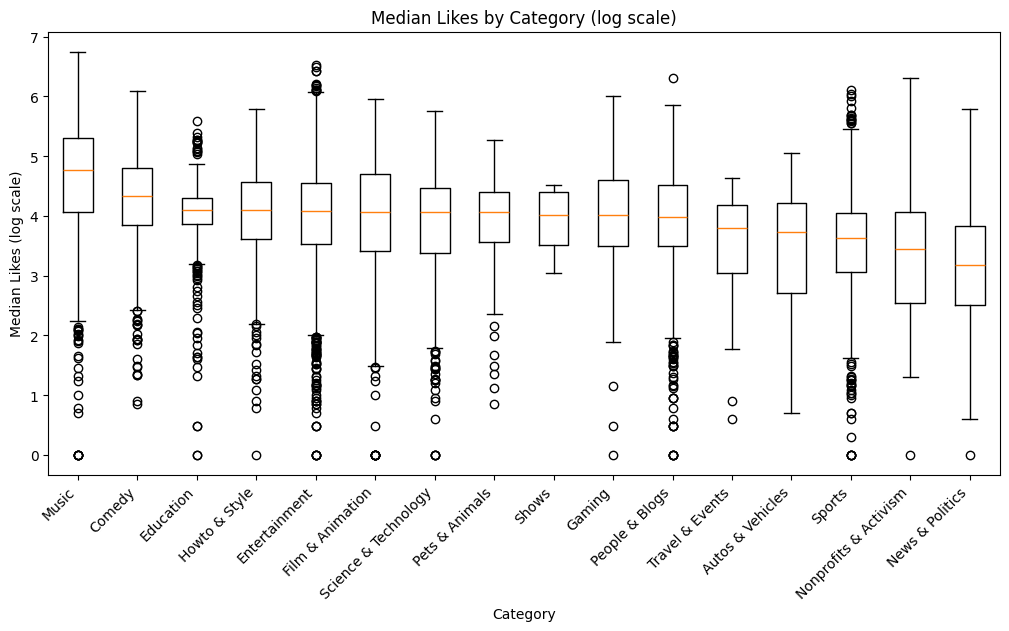

In [25]:
all_df_video['category_name'] = ( #applying category_map to the final dataframe to get new column
    all_df_video['category_id']
    .map(category_map)
)

df = all_df_video.copy() # analysis requires log scale, making copy of df to scale
df['log_likes'] = np.log10(df['likes'] + 1)
# creating new df grouped by category and ordered by median likes
order = df.groupby('category_name', observed=False)['log_likes'].median().sort_values(ascending=False).index
box_mask = [df.loc[df['category_name'] == c, 'log_likes'] for c in order] # mask for a boxplot of each category in same plot
plt.figure(figsize=(10,6))
plt.boxplot(box_mask, tick_labels=order)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.xlabel('Category')
plt.ylabel('Median Likes (log scale)')
plt.title('Median Likes by Category (log scale)')

In [26]:
# Music dominates in median likes while news and politics are the lowest
# Our polorization theory is not being supported still but more calculations to follow
# summary table of median values by categories
summary = (
    all_df_video
    .groupby('category_name', observed=True)
    .agg(
        median_views=('views', 'median'),
        median_likes=('likes', 'median'),
        median_ratio=('likes_to_dislikes', 'median')
    )
    .sort_values('median_views', ascending=False)
)
print(summary)        

                       median_views  median_likes  median_ratio
category_name                                                  
Music                     1654199.0       59316.0     40.269122
Comedy                     784451.0       21279.0     29.717900
Shows                      765522.0       13675.0     27.975304
Film & Animation           726665.0       11760.0     22.614951
Entertainment              616420.5       12008.5     24.478981
Gaming                     462174.5       10336.5     25.917749
Science & Technology       431057.5       11575.5     26.805310
Pets & Animals             392655.0       11486.0     54.722380
Autos & Vehicles           390383.5        5329.0     18.266479
Sports                     376867.5        4223.5     18.122850
Travel & Events            366169.5        6285.5     26.528845
Education                  356063.0       12576.0     33.153050
Howto & Style              332114.0       12422.0     37.671464
People & Blogs             324428.5     

Music is now more than twice the median views as the next category, Comedy. It also shows a high median ratio meaning much lower "polorization."
Meanwhile, News & Politics is second to last with the lowest median ratio. If we accept our polorization theory, News & Politics should be higher on the list, further disproving our client. This table suggest category type is a strong driver of views and shares.

Next I will model regressions with categories and country as possible confounding variables.

In [27]:
# log trasnformed views (add 1 to avoid log(0))
df['log_views'] = np.log10(df['views'] + 1)
# log trasnformed likes
df['log_likes'] = np.log10(df['likes'] + 1)
# Create dislike rate (clean polarization metric)
df['dislike_rate'] = df['dislikes'] / (df['likes'] + df['dislikes'] + 1)
model = smf.ols(
    'log_views ~ dislike_rate + C(category_name) + C(country)',
    data=df
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     76.25
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          3.12e-248
Time:                        12:11:16   Log-Likelihood:                -11120.
No. Observations:                9623   AIC:                         2.228e+04
Df Residuals:                    9605   BIC:                         2.241e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [28]:
# A 1-unit increase in dislike_rate is associated with a 0.38% decrease in log_views.
# This suggests negatively recieved videos are not generating greater reach or views.
# Trying log_likes as a controlled variable
model = smf.ols(
    'log_views ~ dislike_rate + C(category_name) + log_likes',
    data=df
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     2176.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:11:16   Log-Likelihood:                -4130.2
No. Observations:                9623   AIC:                             8296.
Df Residuals:                    9605   BIC:                             8425.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [29]:
# checking engagment rate against dislike rate
df['log_engagment'] = np.log10(df['engagment_rate'] + 1)
model = smf.ols(
    'log_engagment ~ dislike_rate + C(category_name) + C(country)',
    data=df
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          log_engagment   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     67.62
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          2.54e-220
Time:                        12:11:16   Log-Likelihood:                 29828.
No. Observations:                9623   AIC:                        -5.962e+04
Df Residuals:                    9605   BIC:                        -5.949e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

When controlling for category and country, dislike rate shows a slight negative association with views. When controlling additionally for total likes, that relationship reversed, suggesting that among similarly popular videos, disagreement does correspond with a slightly higher reach. However, given the direct causal relationship between views and likes, the results should be interpreted cautiously. 
After correcting the engagement rate function, R^2 dropped from 0.16 to 0.11, meaning before the metric was inflated by capturing volume rather than density, which is what the column should measure. However, the fingings are similar: higher dislike rates are associated with lower engagement having a coefficient of -0.0146. That means more polorization slightly decreases overall engagement which is a direct refutation of the client's theory. 

In conclusion, this analysis examing a few questions including whether highly polarized YouTube videos recieved grater engegement and reach. After exploratoty analysis, quantile comparisions, and regression modeling, the data does not provide strong evidence that polarization drives views.

Key findings include:
- Views are strongly associated with overall engagement metrics including likes and comments.
- The like-to-dislike ratio shows only a weak relationship with views.
- When controlling for category and country, higher dislikes are associated with slightly lower views.
- Adittionally when controlling for likes, the relationship reversed. This effect should be interpreted causiously due to the direct relationship between views and likes, but the implication is that among similarly viewed videos, disagreement does correspond with higher reach.
- Categories explain the most substantial variation in views rather than polarization.

Overall, the evidence suggests that category and likes are stronger predictors of reach than disagreement. While some data implies polorization can generate some views between similarly levels of shared videos, it does not appear to systemically drive higher view counts in this dataset.

It's important to note we are using views as a measurment of "getting shared the most," which is not the most direct. A direct measurment was not provided and future analysis should incorporate true sharing metrics for better analysis.

Category ID, trending date, tags, and even a breakdown of the description columns could also be investigated further. Categories and tags help tell what content is most popular. We could find key words that help uncover viral terms or phrases that help attract view shares or create a sentiment analysis. And while we used publish date as the default datetime measuremnt, trending times can be analyzed for patterns as well, though it would require more dimensional calculations.